In [1]:
import sys
from pathlib import Path

ROOT = Path("../").resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/master_dataset.csv")

print(df.shape)

(2693087, 12)


In [3]:
df["speed_delta"] = (
    df.groupby("session_id")["speed"]
      .diff()
)

In [4]:
df["rpm_delta"] = (
    df.groupby("session_id")["rpm"]
      .diff()
)

In [5]:
df["maf_delta"] = (
    df.groupby("session_id")["maf"]
      .diff()
)

In [6]:
df["map_delta"] = (
    df.groupby("session_id")["map"]
      .diff()
)


In [7]:
df[
    [
        "speed_delta",
        "rpm_delta",
        "throttle_delta",
        "maf_delta",
        "map_delta"
    ]
].describe()

KeyError: "['throttle_delta'] not in index"

In [8]:
print(df.columns.tolist())

['session_id', 'timestamp', 'coolant_temp', 'map', 'rpm', 'speed', 'iat', 'maf', 'throttle_pos', 'ambient_temp', 'pedal_d', 'pedal_e', 'speed_delta', 'rpm_delta', 'maf_delta', 'map_delta']


In [9]:
df["throttle_delta"] = (
    df.groupby("session_id")["throttle_pos"]
      .diff()
)

In [11]:
df[
    [
        "speed_delta",
        "rpm_delta",
        "throttle_delta"
    ]
].head()

,speed_delta,rpm_delta,throttle_delta
0,NaN,NaN,NaN
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [12]:
df[
    [
        "speed_delta",
        "rpm_delta",
        "throttle_delta"
    ]
].head()

,speed_delta,rpm_delta,throttle_delta
0,NaN,NaN,NaN
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [13]:
[col for col in df.columns if "delta" in col]

['speed_delta', 'rpm_delta', 'maf_delta', 'map_delta', 'throttle_delta']

In [14]:
df[
    [
        "speed_delta",
        "rpm_delta",
        "throttle_delta",
        "maf_delta",
        "map_delta"
    ]
].describe()

,speed_delta,rpm_delta,throttle_delta,maf_delta,map_delta
count,2.693006e+06,2.693006e+06,2.693006e+06,2.693006e+06,2.693006e+06
mean,-3.639056e-05,-8.239863e-04,-1.817746e-03,-1.556402e-04,-1.428887e-03
std,5.874300e-01,4.306749e+01,2.622654e+00,1.916238e+00,4.176113e+00
min,-1.060000e+02,-2.703000e+03,-6.980000e+01,-7.867000e+01,-1.600000e+02
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.300000e+01,1.866000e+03,7.530000e+01,9.155000e+01,1.350000e+02


In [15]:
corr_features = [
    "rpm",
    "speed",
    "maf",
    "map",
    "throttle_pos",
    "rpm_delta",
    "speed_delta",
    "maf_delta",
    "map_delta",
    "throttle_delta"
]

df[corr_features].corr()

,rpm,speed,maf,map,throttle_pos,rpm_delta,speed_delta,maf_delta,map_delta,throttle_delta
rpm,1.000000,0.825798,0.766057,0.650259,-0.037869,4.020336e-02,4.911149e-02,5.732498e-04,-2.534895e-02,-2.073238e-02
speed,0.825798,1.000000,0.695210,0.661620,-0.013182,-7.791124e-03,6.458451e-03,-7.597775e-03,-9.517805e-03,7.827873e-04
maf,0.766057,0.695210,1.000000,0.865170,-0.024852,-6.716261e-04,7.042574e-02,5.863898e-02,-1.020131e-02,-8.030489e-03
map,0.650259,0.661620,0.865170,1.000000,0.105419,4.308807e-02,1.035828e-01,1.218681e-02,6.711965e-02,-2.645737e-02
throttle_pos,-0.037869,-0.013182,-0.024852,0.105419,1.000000,6.395579e-02,3.101351e-03,1.780156e-02,4.915428e-02,1.178471e-01
rpm_delta,0.040203,-0.007791,-0.000672,0.043088,0.063956,1.000000e+00,-1.185232e-09,-1.553971e-09,-6.546303e-09,-1.326059e-08
speed_delta,0.049111,0.006458,0.070426,0.103583,0.003101,-1.185232e-09,1.000000e+00,-5.031590e-09,-2.119622e-08,-4.293633e-08
maf_delta,0.000573,-0.007598,0.058639,0.012187,0.017802,-1.553971e-09,-5.031590e-09,1.000000e+00,-2.779061e-08,-5.629434e-08
map_delta,-0.025349,-0.009518,-0.010201,0.067120,0.049154,-6.546303e-09,-2.119622e-08,-2.779061e-08,1.000000e+00,-2.371471e-07
throttle_delta,-0.020732,0.000783,-0.008030,-0.026457,0.117847,-1.326059e-08,-4.293633e-08,-5.629434e-08,-2.371471e-07,1.000000e+00


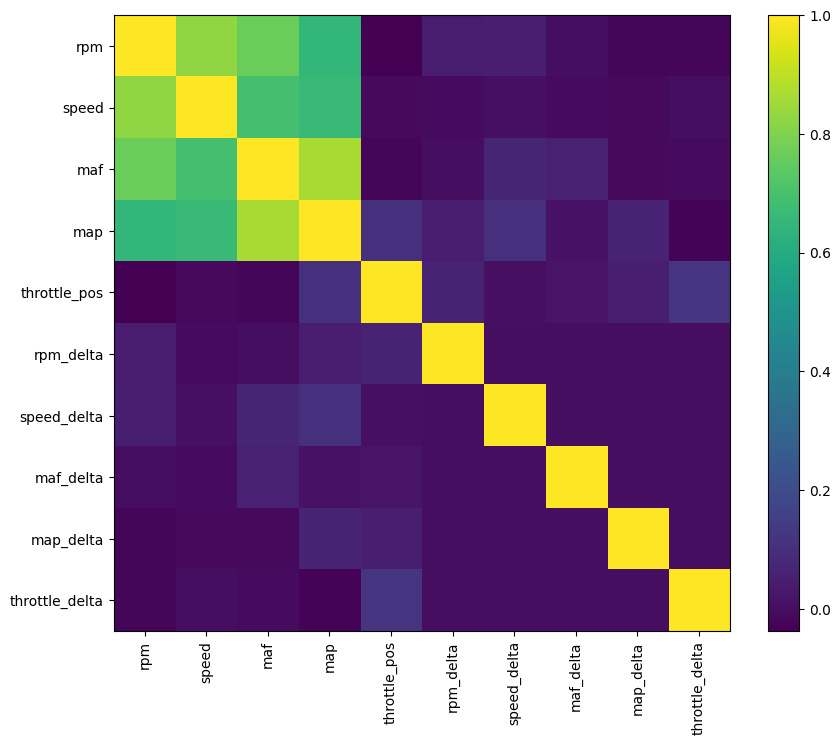

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(df[corr_features].corr())
plt.colorbar()
plt.xticks(range(len(corr_features)), corr_features, rotation=90)
plt.yticks(range(len(corr_features)), corr_features)
plt.show()

In [19]:
from server.analytics.state_classifier import classify_states
classified_df, classification_report = classify_states(df)

print(classified_df.shape)
classified_df["target"] = (
    classified_df["state"]
    .isin(["Acceleration", "Deceleration"])
    .astype(int)
)

(2693087, 18)


In [20]:
classified_df["target"].value_counts()
classified_df["target"].value_counts(normalize=True) * 100

target
0    96.574563
1     3.425437
Name: proportion, dtype: float64

In [21]:
from sklearn.model_selection import train_test_split

sample_df = classified_df.sample(
    n=100000,
    random_state=42
)

sample_df.shape

(100000, 19)

In [22]:
FEATURES = [
    "rpm",
    "speed",
    "maf",
    "map",
    "throttle_pos",
    "rpm_delta",
    "speed_delta",
    "maf_delta",
    "map_delta",
    "throttle_delta",
]

In [23]:
X = sample_df[FEATURES]

y = sample_df["target"]

In [24]:
X = sample_df[FEATURES]

y = sample_df["target"]

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [27]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df

,feature,importance
6,speed_delta,0.639637
5,rpm_delta,0.328081
1,speed,0.009280
0,rpm,0.007519
2,maf,0.007453
3,map,0.005493
4,throttle_pos,0.001402
7,maf_delta,0.000591
8,map_delta,0.000503
9,throttle_delta,0.000041


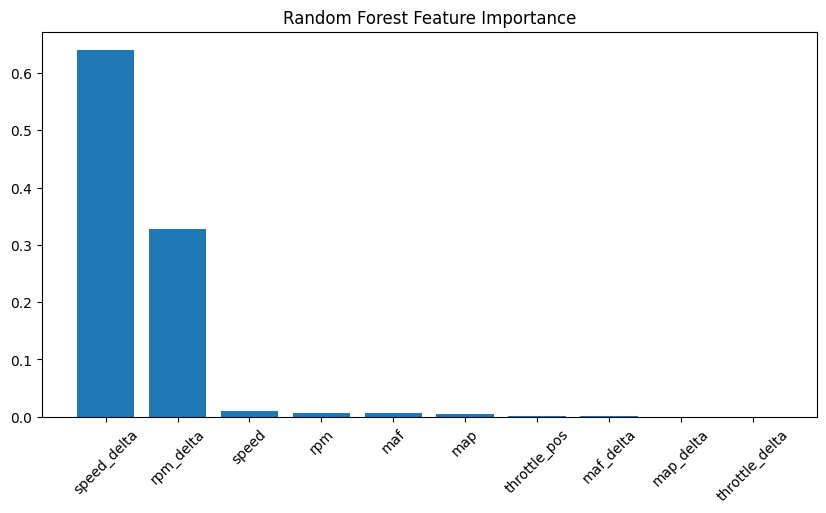

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xticks(rotation=45)

plt.title("Random Forest Feature Importance")

plt.show()

In [ ]:
_